## Problem 4: Neural network regression with TensorFlow

Architecture (fixed): input (population) → **Dense(2, ReLU)** → Dense(1, linear output).

Optimizer (fixed): **stochastic gradient descent** (`batch_size = 1`, so weights update after every sample). Loss: **mean squared error**.

Data: housing prices dataset (population in 10,000s → price in \$10,000s), 70% training / 30% validation.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

data = np.loadtxt('housing_prices.txt', delimiter=',')
x, y = data[:, :1], data[:, 1]

# 70% training / 30% validation
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42)

# Standardize the input with training-set statistics; this keeps the ReLU units
# in a sensible range and lets SGD use a larger learning rate without diverging
mu, sigma = x_train.mean(), x_train.std()
scale = lambda v: (v - mu) / sigma
x_train_s, x_val_s = scale(x_train), scale(x_val)

print('Training samples:', len(y_train), ' Validation samples:', len(y_val))

Training samples: 67  Validation samples: 30


In [3]:
def build_model(learning_rate):
    # Fixed seed so every run starts from the same initial weights
    tf.keras.utils.set_random_seed(42)
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(1,)),
        tf.keras.layers.Dense(2, activation='relu'),
        tf.keras.layers.Dense(1),
    ])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate), loss='mse')
    return model


build_model(0.001).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

### Choosing the learning rate

Train the same network with several learning rates for 100 epochs and compare the validation loss.

               Final train MSE  Final val MSE  Epochs to within 1% of final train MSE
Learning rate                                                                        
0.0001                   8.106         11.322                                      41
0.0010                   8.272         11.767                                       6
0.0100                   9.315         11.846                                      46
0.0500                  33.272         27.553                                       2


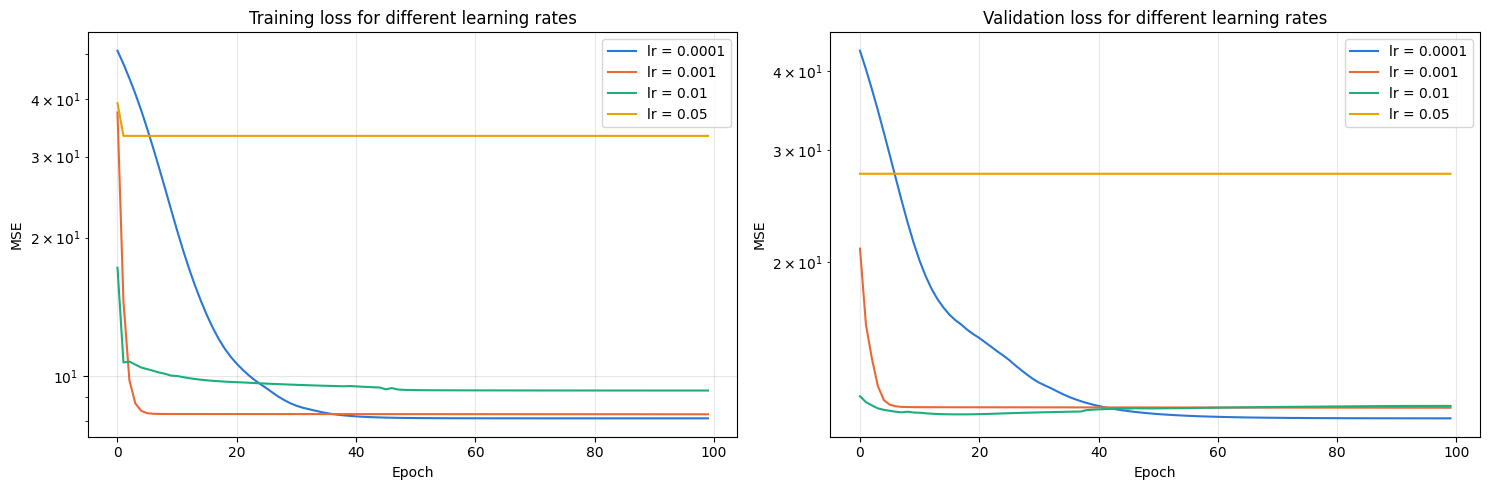

In [4]:
learning_rates = [0.0001, 0.001, 0.01, 0.05]
sweep_epochs = 100
sweep = {}
for lr in learning_rates:
    m = build_model(lr)
    h = m.fit(x_train_s, y_train, validation_data=(x_val_s, y_val),
              epochs=sweep_epochs, batch_size=1, verbose=0)
    sweep[lr] = h.history

summary = pd.DataFrame({
    'Final train MSE': [sweep[lr]['loss'][-1] for lr in learning_rates],
    'Final val MSE': [sweep[lr]['val_loss'][-1] for lr in learning_rates],
    'Epochs to within 1% of final train MSE': [
        int(np.argmax(np.array(sweep[lr]['loss']) <= 1.01 * sweep[lr]['loss'][-1])) + 1 for lr in learning_rates],
}, index=pd.Index(learning_rates, name='Learning rate')).round(3)
print(summary.to_string())

colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for lr, c in zip(learning_rates, colors):
    ax1.plot(sweep[lr]['loss'], color=c, label=f'lr = {lr}')
    ax2.plot(sweep[lr]['val_loss'], color=c, label=f'lr = {lr}')
for ax, title in [(ax1, 'Training loss'), (ax2, 'Validation loss')]:
    ax.set_yscale('log')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_title(f'{title} for different learning rates')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **lr = 0.05** is too large. The first few updates push both hidden neurons into the region where ReLU outputs zero for every input ("dead" neurons). The network then outputs a constant (≈ the mean price), and the loss is stuck at the highest value.
- **lr = 0.01** converges quickly but settles at a worse solution. Single-sample SGD steps are large enough to push one neuron into an awkward kinked shape, so its training loss plateaus higher (≈9.3) than the smaller learning rates.
- **lr = 0.0001** is stable but slow: it needs roughly 40 epochs to converge. Its final losses are only marginally lower than lr = 0.001.
- **lr = 0.001** gives the best trade-off. It converges within about 5 to 10 epochs, is stable, and reaches essentially the same low plateau.

**Chosen:** learning rate = 0.001, 100 epochs. Both losses are flat well before 100 epochs, so training longer does not improve the validation loss. 100 epochs leaves a comfortable margin past convergence.

Final training MSE:   8.2724
Final validation MSE: 11.7673


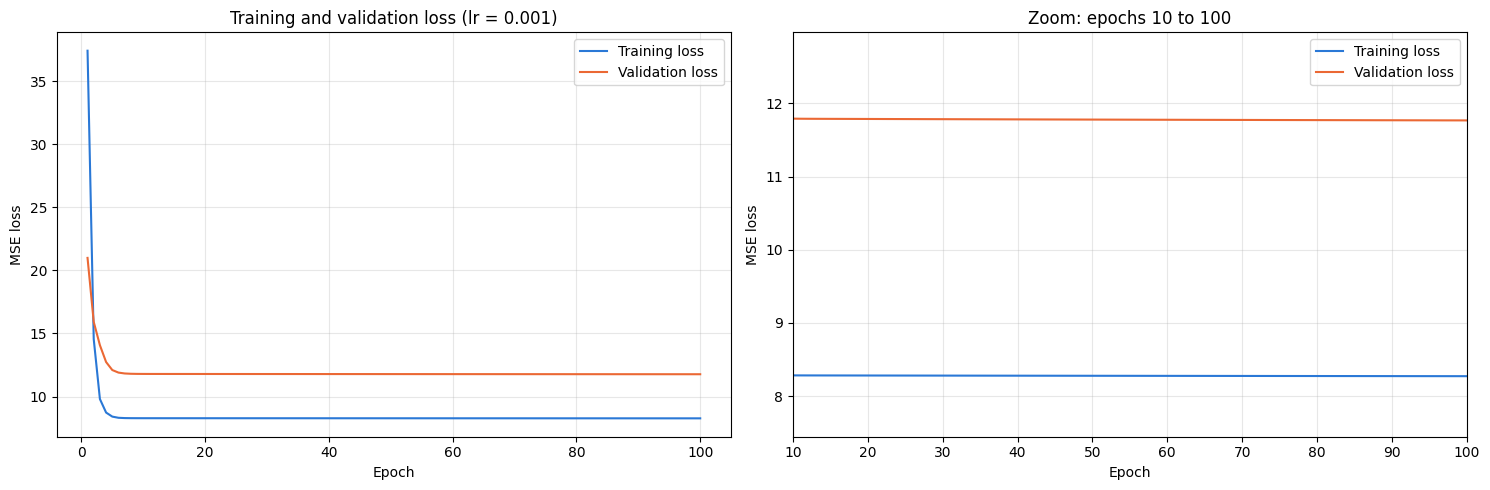

In [5]:
learning_rate = 0.001
epochs = 100

model = build_model(learning_rate)
history = model.fit(x_train_s, y_train, validation_data=(x_val_s, y_val),
                    epochs=epochs, batch_size=1, verbose=0)

train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
print(f'Final training MSE:   {train_loss[-1]:.4f}')
print(f'Final validation MSE: {val_loss[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for ax in (ax1, ax2):
    ax.plot(np.arange(1, epochs + 1), train_loss, color='#2a78d6', label='Training loss')
    ax.plot(np.arange(1, epochs + 1), val_loss, color='#eb6834', label='Validation loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.legend()
    ax.grid(alpha=0.3)
ax1.set_title(f'Training and validation loss (lr = {learning_rate})')
ax2.set_xlim(10, epochs)
ax2.set_ylim(0.9 * train_loss[9:].min(), 1.1 * val_loss[9:].max())
ax2.set_title('Zoom: epochs 10 to 100')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pred_train = model.predict(x_train_s, verbose=0).ravel()
pred_val = model.predict(x_val_s, verbose=0).ravel()

# Ordinary least-squares line fit on the same training data, as a reference
slope, intercept = np.polyfit(x_train.ravel(), y_train, 1)
lin_val = slope * x_val.ravel() + intercept

def regression_metrics(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE ($10,000s)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE ($10,000s)': mean_absolute_error(y_true, y_pred),
        'R^2': r2_score(y_true, y_pred),
    }

pd.DataFrame({
    'NN - training': regression_metrics(y_train, pred_train),
    'NN - validation': regression_metrics(y_val, pred_val),
    'Linear fit - validation': regression_metrics(y_val, lin_val),
}).round(4)

,NN - training,NN - validation,Linear fit - validation
MSE,8.1237,11.7673,11.2674
"RMSE ($10,000s)",2.8502,3.4304,3.3567
"MAE ($10,000s)",2.1715,2.2031,2.1572
R^2,0.7392,0.5724,0.5905


### Findings

**Prediction.** For a city of **165,000** people, the trained network predicts a house price of **≈ 16.88 × \$10,000 = \$168,775**.

**Regression metrics** (learning rate 0.001, 100 epochs):

| | MSE | RMSE (\$10k) | MAE (\$10k) | R² |
|---|---|---|---|---|
| NN, training | 8.12 | 2.85 | 2.17 | 0.739 |
| NN, validation | 11.77 | 3.43 | 2.20 | 0.572 |
| Straight-line least squares, validation | 11.27 | 3.36 | 2.16 | 0.591 |

On the validation set, typical errors are about \$22,000 (MAE) to \$34,000 (RMSE). The network explains about 57% of the variance in price. It performs about as well as a straight-line fit. With two ReLU units, the learned function is piecewise linear with kinks at populations of about 47,700 and 79,400. The first kink lies below the smallest city in the data (50,300), so over the data range the model is two nearly-collinear line segments. The data is essentially linear, so a more complex curve has nothing to gain.

**Trends in the training and validation loss plots**
1. **Rapid initial drop, then a plateau.** With `batch_size = 1`, each epoch performs 67 weight updates, so both losses fall sharply within the first ~5 epochs. Training MSE drops from 37.4 to 8.4, and validation MSE from 21.0 to 12.1. After about epoch 10, both curves are essentially flat (training ≈ 8.3, validation ≈ 11.8). The model has converged, and further epochs change the loss only in the third decimal place.
2. **Validation loss is below training loss in epoch 1.** Keras reports the training loss as the average over all updates during the epoch, including the early updates when the weights were still poor. The validation loss is evaluated with the weights at the end of the epoch. The same effect explains why the reported final training loss (8.27) is slightly higher than the MSE recomputed after training (8.12).
3. **Validation loss stays above training loss, but this is not overfitting.** The gap is constant, and the validation loss never turns upward. The network has only 7 parameters, far too few to memorize 67 points. The gap is caused by one validation point, (population 61,101, price \$175,920), which lies far above the trend. The model predicts ≈ \$30,300 there, and that single squared error accounts for **60%** of the validation MSE. Without it, validation MSE drops to 4.86 (R² = 0.79), which is lower than the training MSE. With only 30 validation samples, one outlier dominates the metric.
4. **The model's limit is the noise in the data, not training.** Training and validation losses both plateau at a level set by the scatter of prices around a straight line. The straight-line baseline reaches the same validation error. Neither more epochs nor a different learning rate can reduce the loss further with this fixed architecture.